# Estimate diameter from phase function

In [1]:
import requests
import time
import io
import os

import numpy as np
import pandas as pd

import rocks

from figure_mask import compute_mask, print_statistics

import matplotlib.pyplot as plt

# import seaborn as sns
# sns.set_context("poster")

### Combination BFT & SSOFT

In [2]:
cols = [
    "sso_number",
    "sso_name",
    "sso_class",
    "albedo.value",
    "diameter.value",
]

# Read BFT with rocks
bft = rocks.load_bft(columns=cols)

In [3]:
# bft[bft["spins.1.period.value"] == bft["spins.1.period.value"]].groupby("spins.1.period_flag").count()

In [4]:
print(
    "{:,} diameters available in the BFT".format(len(bft[bft["albedo.value"].notna()]))
)

149,470 diameters available in the BFT


In [5]:
# You need SSOFT version 2024.09
# see fink_spins/generate_data.py
data_fink = "../../"
ssoft = pd.read_parquet(os.path.join(data_fink, "data", "ztf", "sso_ZTF.parquet"))

In [6]:
flavor = "SHG1G2"

## Comparison to literature

In [7]:
# Keep only known periods 1 in the BFT
data = ssoft.merge(bft, left_on="name", right_on="sso_name", how="left")
data = data[data["albedo.value"].notna()]

# sort by number of observations
data = data.sort_values("n_obs", ascending=False)
# data = data.sort_values(f'{flavor}_rms', ascending=False)

col_display = [
    "sso_number",
    "sso_name",
    "n_obs",
    "sso_class",
    "albedo.value",
    f"{flavor}_period",
    f"{flavor}_rms",
]

if flavor == "SHG1G2":
    col_display.append(f"{flavor}_R")

cond = data.sso_class.str.contains("Inner")
# cond = (data['spins.1.technique']=='LCI') & ( np.abs(data['spins.1.period.value']-data['SSHG1G2_period']) < 0.1)

data.loc[cond, col_display].head(5)

,sso_number,sso_name,n_obs,sso_class,albedo.value,SHG1G2_period,SHG1G2_rms,SHG1G2_R
63906,5518,Mariobotta,451.0,MB>Inner,0.2012,33.183693,0.169943,0.789760
84016,21814,Shanawolff,431.0,MB>Inner,0.2405,2.499411,0.056240,0.865430
30332,1928,Summa,409.0,MB>Inner,0.1469,48.055374,0.116187,0.300000
51067,2200,Pasadena,405.0,MB>Inner,0.1962,20.530388,0.068762,0.818853
91906,5350,Epetersen,394.0,MB>Inner,0.2233,4.549254,0.111522,0.746113


In [8]:
print(
    "{:,} albedo available in the BFT x Fink".format(
        len(data[data["albedo.value"].notna()])
    )
)

77,121 albedo available in the BFT x Fink


### Mask

It is not obvious yet what are the criteria for good period estimation, so let's stick with masks defined for sHG1G2

In [9]:
maskFINK_inter = compute_mask(
    ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.30, model="FINK", kind="inter"
)
maskFINK_union = compute_mask(
    ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.30, model="FINK", kind="union"
)

for model in ["HG", "HG1G2", "SHG1G2", "FINK"]:
    print_statistics(ssoft, model)
    print()

mask = maskFINK_union
mask = maskFINK_inter
print(sum(mask))

  All data       : 140559  (100.00%)
  Mask HG (g∩r) : 137746  ( 98.00%)
  Mask HG (gUr) : 137752  ( 98.00%)

  All data       : 140559  (100.00%)
  Mask HG1G2 (g∩r) :  57578  ( 40.96%)
  Mask HG1G2 (gUr) : 101207  ( 72.00%)

  All data       : 140559  (100.00%)
  Mask SHG1G2 (g∩r) :  76798  ( 54.64%)
  Mask SHG1G2 (gUr) : 114519  ( 81.47%)

  All data       : 140559  (100.00%)
  Mask FINK (g∩r) :  57198  ( 40.69%)
  Mask FINK (gUr) :  95470  ( 67.92%)

57198


In [10]:
print(
    "{:,} albedo available in the MASK(BFT x Fink)".format(
        len(data[data["albedo.value"].notna()][mask])
    )
)

33,447 albedo available in the MASK(BFT x Fink)


/tmp/ipykernel_12833/3483294913.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(data[data["albedo.value"].notna()][mask])


### Period distribution

In [11]:
data.columns[data.columns.str.contains("SSH")]

Index(['SSHG1G2_fit', 'SSHG1G2_status', 'SSHG1G2_chi2red',
       'SSHG1G2_min_cos_lambda', 'SSHG1G2_mean_cos_lambda',
       'SSHG1G2_max_cos_lambda', 'SSHG1G2_rms', 'SSHG1G2_rms_g',
       'SSHG1G2_rms_r', 'SSHG1G2_median_error_phot',
       'SSHG1G2_median_error_phot_1', 'SSHG1G2_median_error_phot_2',
       'SSHG1G2_alpha0', 'SSHG1G2_dalpha0', 'SSHG1G2_delta0',
       'SSHG1G2_ddelta0', 'SSHG1G2_period', 'SSHG1G2_err_period',
       'SSHG1G2_a_b', 'SSHG1G2_da_b', 'SSHG1G2_a_c', 'SSHG1G2_da_c',
       'SSHG1G2_phi0', 'SSHG1G2_dphi0', 'SSHG1G2_H_g', 'SSHG1G2_dH_g',
       'SSHG1G2_G1_g', 'SSHG1G2_dG1_g', 'SSHG1G2_G2_g', 'SSHG1G2_dG2_g',
       'SSHG1G2_H_r', 'SSHG1G2_dH_r', 'SSHG1G2_G1_r', 'SSHG1G2_dG1_r',
       'SSHG1G2_G2_r', 'SSHG1G2_dG2_r', 'SSHG1G2_period_chi2red',
       'SSHG1G2_obliquity', 'SSHG1G2_alpha0_alt', 'SSHG1G2_delta0_alt',
       'SSHG1G2_flag'],
      dtype='object')

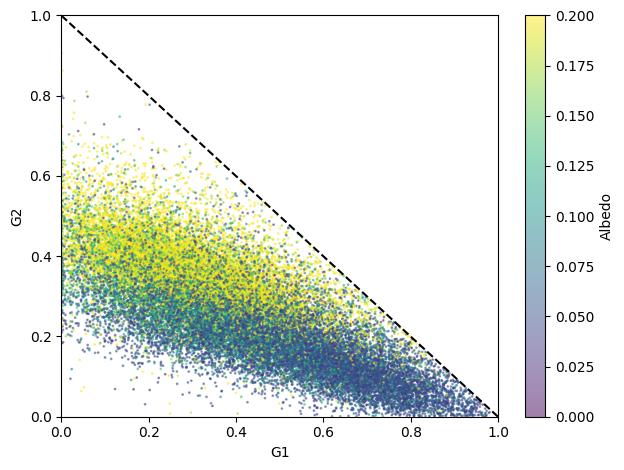

In [12]:
fig, ax = plt.subplots()  # figsize=(14, 8))

filt = "r"
im = ax.scatter(
    data.loc[mask, f"{flavor}_G1_{filt}"],
    data.loc[mask, f"{flavor}_G2_{filt}"],
    c=data.loc[mask, "albedo.value"],
    vmin=0,
    vmax=0.2,
    s=1,
    alpha=0.5,
)

x = np.linspace(0, 1, 10)
ax.plot(x, 1 - x, color="black", linestyle="--")

cbar = fig.colorbar(im, label="Albedo")

# Axes
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_ylabel("G2")
ax.set_xlabel("G1")

fig.tight_layout()

## Regression


In [13]:
# Prepare data
X = data.loc[mask, [f"{flavor}_G1_{filt}", f"{flavor}_G2_{filt}"] ].to_numpy()
y = data.loc[mask, "albedo.value"].to_numpy()


In [14]:
# Compute regression
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import RadiusNeighborsRegressor



for reg in [LinearRegression(), RadiusNeighborsRegressor(radius=0.005)]:
# for reg in [LinearRegression()]:
    model = make_pipeline(reg)
    model[0].fit(X, y)
    score = model[0].score(X, y)
    print( score )

0.3685294128898208
0.509103101066791


In [15]:
# Compute regression
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X, y)
print(reg.score(X, y))

0.3685294128898208


In [16]:
from sklearn.neighbors import RadiusNeighborsRegressor

neigh = RadiusNeighborsRegressor(radius=0.005)
neigh.fit(X, y)

print(neigh.score( X, y))

0.509103101066791


In [34]:
# Build output map
N = 201
xy = np.array([(i, j) for j in np.linspace(0,1,num=N) for i in np.linspace(0,1,num=N)])

z = np.tril(reg.predict(xy).reshape(N,N)[::-1])

unity = np.triu(np.full((N,N), 1))
z = z+unity

# z = reg.predict(xy).reshape(N,N)
# z = neigh.predict(xy).reshape(N,N)


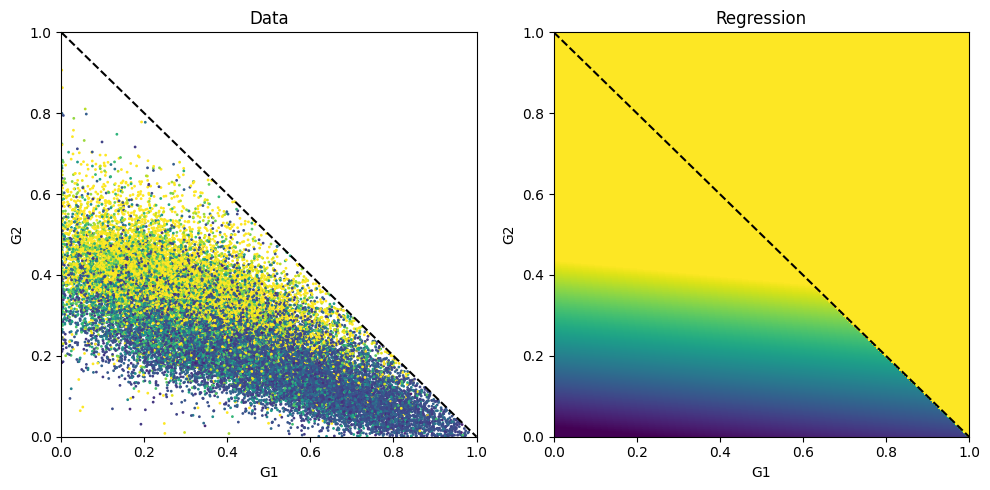

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

filt = "r"
im = ax[0].scatter(
    data.loc[mask, f"{flavor}_G1_{filt}"],
    data.loc[mask, f"{flavor}_G2_{filt}"],
    c=data.loc[mask, "albedo.value"],
    vmin=0,
    vmax=0.2,
    # cmap='afmhot',
    s=1,
    alpha=1,
)

ax[1].imshow(z, extent=(0,1,0,1), vmin=0, vmax=0.2, aspect='auto')
# ax[1].imshow(z, extent=(0,1,0,1), origin='lower', vmin=0, vmax=0.2, aspect='auto')

# cbar = fig.colorbar(im, ax=ax[1], label="Albedo")

# Axes
x = np.linspace(0, 1, 10)
for a in ax:

    a.plot(x, 1 - x, color="black", linestyle="--")
    a.set_xlim(0, 1)
    a.set_ylim(0, 1)
    a.set_ylabel("G2")
    a.set_xlabel("G1")

ax[0].set_title("Data")
ax[1].set_title("Regression")

fig.tight_layout()
fig.savefig("/home/bcarry/G1G2_albedo_regression.png")